░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
# EPOS and ECMWF: Seismic Events with Climate Context

## Description: 
             The script processes earthquake event data from EPOS Platform, flags events
             potentially influenced by climate interactions, fetches available seismic
             waveforms for these flagged events from different platform (GFZ), performs P/T phase
             picking using the STA/LTA algorithm (Optional). It then integrates
             ECMWF (ERA5) cumulative precipitation data for the identified events
             to assess potential connection with monsoon conditions.
             Finally, it saves all relevant outputs into a single
             multimodal pickle file for comprehensive data archiving.
             
### Technical Objectives: 
             Access to ECMWF data platform, and retrieve climate variables.

### Target Audience: 
             Students of seismology, geophysics, environmental science.
░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

In [3]:
# ░░░░░░░░░░░░░░░░░░░░  Auto-installer (run once)  ░░░░░░░░░░░░░░░░░░░░
# one-shot installer 
# Change / trim packages if your workflow differs.  Remove --quiet for full logs

#!pip install --quiet --upgrade \                       # ── Install the latest available versions of these packages, suppressing most of the usual download/build chatter.
#    numpy pandas matplotlib tqdm \                     # ── core PyData stack
#    obspy \                                            # ── seismic waveforms, STA/LTA picker
#    cdsapi xarray netCDF4 cfgrib \                     # ── ERA-5 data download + NetCDF/GRIB handling
#    cartopy shapely pyproj descartes \                 # ── maps / projections / geometry for epicentre plots
#    rasterio pillow                                    # ── raster I/O & PNG/JPEG support

# ░░░░░░░░░░░░░░░░░░░░  End auto-installer  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░

In [4]:
# Packages  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from obspy import UTCDateTime, Trace
from obspy.clients.fdsn import Client                           # Reduce heavy-lifting in connecting onto api
from obspy.signal.trigger import classic_sta_lta, trigger_onset

import cdsapi                                                   # Import the Copernicus CDS API client 
import pickle                                                   # For saving multimodal data
import xarray as xr                                             # For handling NetCDF data                                                 

from tqdm import tqdm                                           # For progress bars when downloading data
from epos_school_function import *                              # Customized functions only for this exercise

import pathlib as Path, pathlib
from datetime import datetime, timezone


In [5]:
# Functions ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

def _quick_plot(tr, p_time, t_time, net, sta, cha):
    # --- Plotting --- HERE IS THE ISSUES (from here > from epos_function import *)
    # Create a new figure for plotting the seismogram.
    plt.figure(figsize=(15, 5))
    # Convert trace times to matplotlib-compatible dates for plotting.
    times = tr.times("matplotlib")
    # Plot the seismic trace data.
    plt.plot(times, tr.data, color="k", label="Ground motion")

    # If a P-phase was detected, add a vertical dashed blue line to the plot.
    if p_time:
        plt.axvline(p_time.matplotlib_date, color="b", linestyle="--", label="P arrival")
    # If a T-phase was detected, add a vertical dashed green line to the plot.
    if t_time:
        plt.axvline(t_time.matplotlib_date, color="g", linestyle="--", label="T phase (end)")
        # Highlight the detected earthquake window in red, from P-phase to T-phase.
        plt.axvspan(p_time.matplotlib_date if p_time else times[0],
                    t_time.matplotlib_date, color="red", alpha=0.2, label="Detected earthquake")
    plt.legend() # Display the legend for the plot lines.
    # Set the title of the plot.
    plt.title(f"Seismogram at {net}.{sta} ({cha})\nP-phase (blue), End (green), Shaking (red)")
    plt.xlabel("Time (UTC)") # Label for the x-axis.
    plt.ylabel("Counts") # Label for the y-axis.
    plt.show() # Display the plot.

#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
## 1. Load and flag events
#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

In [36]:
# Documentation for this section:
# ------------------------------
#
# This section focuses on loading earthquake catalog data from EPOS (.csv file) and applying
# filters to identify events that might exhibit a "probable climate interaction."
# This flagging is based on three primary criteria: event depth, epicentral
# region, and time of year (monsoon season).

# This initial filtering aims to pre-select earthquakes that are shallow,
# occur in regions known for significant hydrological cycles (like the Himalayas
# and surrounding areas), and happen during the peak monsoon season. These
# conditions are hypothesized by various studies to potentially influence
# seismicity through mechanisms such as surface loading, pore-pressure changes,
# and altered crustal stress states due to water mass variations.
#
# 1.1. Data Loading and Initial Cleaning:
#      The script starts by loading a CSV file containing earthquake parameters.
#      "Origin time" is converted to datetime objects, and rows with missing
#      critical information (Origin time, Epicentre latitude, Epicentre longitude, Depth)
#      are removed to ensure data quality for subsequent analysis.
#
# 1.2. Marking Shallow Events (`is_shallow`):
#      Events with a depth less than or equal to 10 km (10000 meters) are flagged
#      as 'shallow'. Shallow earthquakes are more susceptible to surface processes
#      compared to deeper events.
#      • Bettinelli et al., 2008, Nature Geoscience (DOI:10.1038/ngeo251)
#      • Craig et al., 2017, Nature Communications (DOI:10.1038/ncomms15696)
#      These studies provide strong evidence for hydrological/surface loading
#      effects influencing seismicity at these depths.
#
# 1.3. Marking Events in Climate-Sensitive Regions (`is_climate_region`):
#      A predefined list of keywords (e.g., "nepal", "myanmar", "sumatra") is used
#      to identify events occurring in regions recognized for their strong
#      climate-tectonic interactions, particularly those affected by large
#      seasonal hydrological changes (e.g., monsoon).
#      Regions and keywords justified by:
#      • Bettinelli et al., 2008, Nature Geoscience (DOI:10.1038/ngeo251)
#      • Amos et al., 2014, Nature (DOI:10.1038/nature13202)
#      • Pérez-Guillén et al., 2022, GRL (DOI:10.1029/2022GL100746)
#      • Mayer et al., 2014, Earth Surf Dyn (DOI:10.5194/esurf-2-455-2014)
#      • Sun et al., 2020, JGR (DOI:10.1029/2019JB018823)
#
# 1.4. Monsoon Season Definition (`is_monsoon`):
#      The monsoon season is defined for events occurring between May and September
#      (inclusive, months 5 to 9). This period broadly corresponds to the South Asian
#      summer monsoon, which brings significant precipitation and hydrological loading.
#      • The South Asian (Indian) summer monsoon typically spans June–September
#        (e.g., Turner & Annamalai, 2012, Nature Communications, DOI:10.1038/ncomms1794)
#      • Some Himalayan regions experience early pre-monsoon rain from May onward
#        (e.g., Bookhagen & Burbank, D.W., 2010, Nature Geoscience, DOI:10.1038/ngeo907)
#      • Multiple studies have shown earthquake rates and stresses may correlate with
#        monsoon precipitation and its lagged effects on groundwater, snowmelt, or pore pressure
#        (Bettinelli et al., 2008, Nature Geoscience, DOI:10.1038/ngeo251;
#        Amos et al., 2014, Nature, DOI:10.1038/nature13202)
#
# 1.5. Probable Climate Interaction Flag (`probable_climate_interaction`):
#      An event is flagged with "probable_climate_interaction" if all three conditions
#      (is_shallow, is_climate_region, and is_monsoon) are met.
#      It's crucial to note that this "probable" flag serves as a preliminary filter
#      and a hypothesis generator. Actual causality in climate-tectonic interactions
#      is highly complex and involves factors not directly observed here, such as:
#      - Lagged effects: Groundwater percolation and pore-pressure diffusion can have
#        delays ranging from days to months depending on the specific geology
#        (Bettinelli et al., 2008).
#      - Interplay of phenomena: Interactions between snowmelt, direct precipitation,
#        and antecedent water load.
#      - Fault criticality: The existing state of stress on a fault system also plays a
#        significant role, which is not accounted for in this simple model.
#      Therefore, this flag is a necessary but not sufficient indicator and should be
#      treated as a starting point for more in-depth investigations.
# ----------------------------------------------------------------------------

In [6]:
# Construct the full path to the CSV file
csv_path = os.path.join(os.getcwd(), "epos_data", "Parameters of modern earthquakes (1998-present) - FDSN event-2.csv")


# Load the CSV data into a pandas DataFrame
original_df = pd.read_csv(csv_path) # Store the original for pickling


# Create a working copy of the DataFrame for processing
df = original_df.copy()


# Convert the "Origin time" column to datetime objects. 'coerce' will turn
# unparseable dates into NaT (Not a Time).
df["Origin time"] = pd.to_datetime(df["Origin time"], errors="coerce")


# Drop rows where critical columns have missing values (NaN/NaT), ensuring
# complete data for analysis.
df = df.dropna(subset=["Origin time", "Epicentre latitude", "Epicentre longitude", "Depth"])

# Define keywords for identifying climate-sensitive regions. These are based on
# geographical areas known for significant hydrological cycles and seismic activity.
region_keywords = [
    "nepal", "myanmar", "xizang", "hindu kush", "tajikistan", "sumatra",
    "india", "sikkim", "china", "pamir"
]

# Create a boolean column 'is_shallow': True if Depth is 10 km or less (10000 meters).
df["is_shallow"] = df["Depth"] <= 10000   # depth ≤ 10 km (metres); adjust this threshold as needed


# Create a boolean column 'is_climate_region': True if any of the region_keywords
# are found in the 'Epicentral area' (case-insensitive).
df["is_climate_region"] = df["Epicentral area"].str.lower().apply(lambda area: any(kw in area for kw in region_keywords))

# Extract the month from the 'Origin time'
df["month"] = df["Origin time"].dt.month

# Create a boolean column 'is_monsoon': True if the month falls between May (5) and September (9).
df["is_monsoon"] = df["month"].between(5, 9)

# Create a boolean column 'probable_climate_interaction': True if an event
df["is_big_mag"] = pd.to_numeric(df["Magnitude value"], errors="coerce") >= 4.5

df["probable_climate_interaction"] = (
    df["is_shallow"]        &        # depth ≤ 10 km
    df["is_climate_region"] &        # in target hydrological belt
    df["is_monsoon"]        &        # May–Sep
    df["is_big_mag"]                 # Mw ≥ 4.5  ← NEW
)

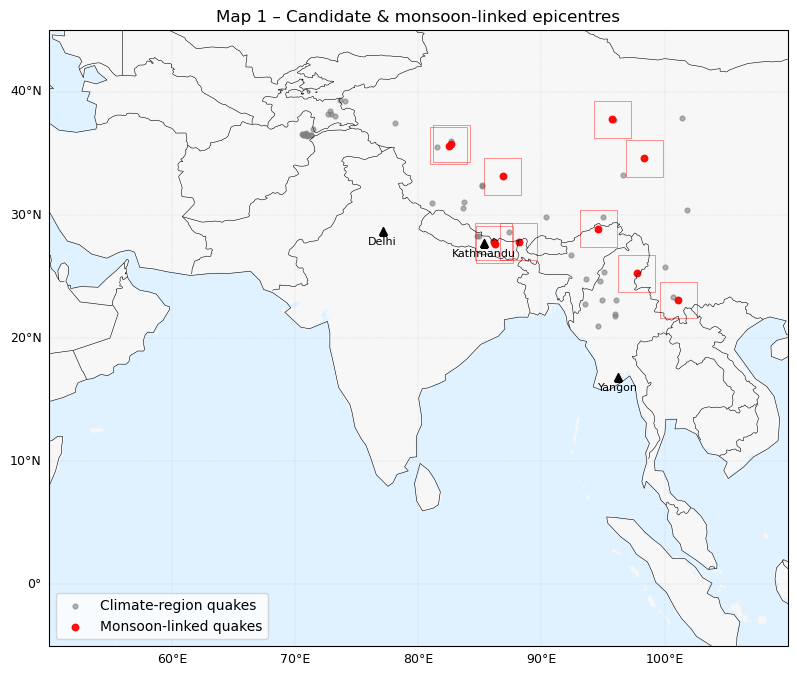

<GeoAxes: title={'center': 'Map 1 – Candidate & monsoon-linked epicentres'}>

In [7]:
# --------------------------------------------------------------------------------------------------
# 📍  Generic epicentre plotting helper 1
# --------------------------------------------------------------------------------------------------


plot_epicentre_map(df, title="Map 1 – Candidate & monsoon-linked epicentres")

#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
## 2. For events with waveforms, plot, and tabulate
#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

In [33]:
# Documentation for this section:
# ------------------------------

# This section iterates through the events flagged as "probable_climate_interaction"
# to attempt to retrieve seismic waveform data, plot the waveforms, and
# tabulate the results.

# Optional: perform automated P- and S-phase
# (or generally, onset and end of strong shaking) picking using the Short-Term
# Average/Long-Term Average (STA/LTA) algorithm. The STA/LTA algorithm is a common method for automated
# detection of seismic phases.

# Seismograms provide the ground motion recordings necessary to identify
# earthquake arrivals. 
#
# 2.1. FDSN Client Initialization:
#      An ObsPy FDSN client is initialized, pointing to the GFZ data center.
#      ObsPy is a powerful Python toolbox for seismology, providing tools to
#      access seismic data from various global data centers.
#      • ObsPy Project (https://docs.obspy.org/)
#
# 2.2. Iterating through Flagged Events:
#      The script loops through each earthquake event previously flagged with
#      'probable_climate_interaction'. For each event, it attempts to:
#
#      a. Find Nearby Stations:
#         Uses `client.get_stations` to query for broadband (channel "BH?")
#         seismic stations within a 2-degree radius of the earthquake's
#         epicenter. `level="response"` ensures that instrument response
#         information is also retrieved, which is crucial for proper data
#         processing.
#
#      b. Fetch Waveforms:
#         If a suitable station is found, `client.get_waveforms` is used to
#         download 30 minutes of waveform data starting from the earthquake's
#         origin time. This window is expected to contain the P-wave arrival
#         and subsequent phases.
#
#      c. Pre-processing Waveforms: (Optional)
#         - `st.detrend("demean")`: Removes the mean from the trace,
#           essential for stable STA/LTA calculations.
#         - `st.filter("bandpass", freqmin=0.02, freqmax=2)`: Applies a
#           bandpass filter to remove very low-frequency noise (e.g., tides)
#           and high-frequency noise, focusing on the frequency range typical
#           for teleseismic earthquake signals.
#
#      d. STA/LTA Phase Picking: (Optional)
#         - `classic_sta_lta(tr.data, nsta, nlta)`: Computes the STA/LTA ratio.
#           The STA/LTA algorithm works by comparing the average amplitude of
#           the seismic signal over a short-term window (STA) to that over a
#           long-term window (LTA). A significant increase in this ratio indicates
#           an arrival.
#           • STA (Short-Term Average) window: `nsta` samples (here, 1 second).
#           • LTA (Long-Term Average) window: `nlta` samples (here, 20 seconds).
#           The choice of these window lengths depends on the signal characteristics
#           and noise levels.
#           • Trani, D., 2010. Automated Real-time Detection of Seismic Events.
#             (Masters thesis, Politecnico di Torino)
#           • Allen, R. V., 1978. Automatic earthquake recognition and timing
#             from single traces. Bulletin of the Seismological Society of America,
#             68(5), 1521-1532.
#         - `trigger_onset(cft, 3, 1)`: Applies a threshold-based trigger to the
#           STA/LTA characteristic function (`cft`). It identifies the start (P-phase)
#           when the `cft` crosses an 'on' threshold (here, 3) and the end (T-phase/end of strong shaking)
#           when it falls below an 'off' threshold (here, 1).
#           The `on_of` variable contains a list of [start_sample, end_sample] pairs.
#
#      e. Arrival Time Calculation: (Optional)
#         Converts the detected sample indices (P-sample, T-sample) into
#         UTCDateTime objects using the trace's start time and sampling rate.
#
#      f. Plotting Waveforms and Picks:
#         Uses Matplotlib to plot the raw seismic trace.
#         A red shaded region highlights the detected earthquake window.
#         This visual representation helps in validating the automated picks.
#
#      g. Tabulating Event Information:
#         Key details about the event, including its origin time, epicentral
#         information, magnitude, depth, and the newly picked P/T phase times,
#         along with the station and channel used, are appended to `event_table`.
#         This forms a structured summary of the processed events.
#
# 2.3. Error Handling:
#      A `try-except` block is used to gracefully handle cases where waveform
#      data cannot be fetched (e.g., no station found, network issues) and prints
#      an informative error message.
# ----------------------------------------------------------------------------


=== Event 8 at (34.58, 98.36) on 2021-05-21T18:04:14.500000Z ===
   Could not fetch seismogram for this event: No data available for request.
HTTP Status code: 204
Detailed response of server:



=== Event 11 at (33.12, 86.87) on 2020-07-22T20:07:19.200000Z ===
   Using station: XF.ST23A (BHN)
   Could not fetch seismogram for this event: No data available for request.
HTTP Status code: 204
Detailed response of server:



=== Event 12 at (35.60, 82.49) on 2020-06-25T21:05:18.400000Z ===
   Could not fetch seismogram for this event: No data available for request.
HTTP Status code: 204
Detailed response of server:



=== Event 27 at (27.62, 86.21) on 2015-05-12T07:36:52.900000Z ===
   Using station: IO.EVN (BHE)


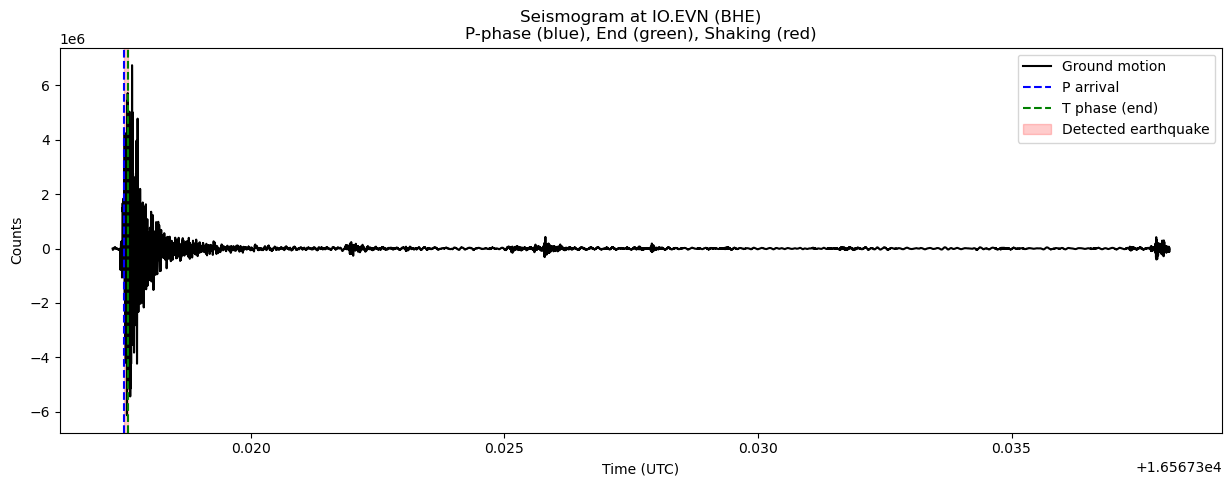


=== Event 28 at (27.83, 86.14) on 2015-05-12T07:05:18.700000Z ===
   Using station: IO.EVN (BHE)


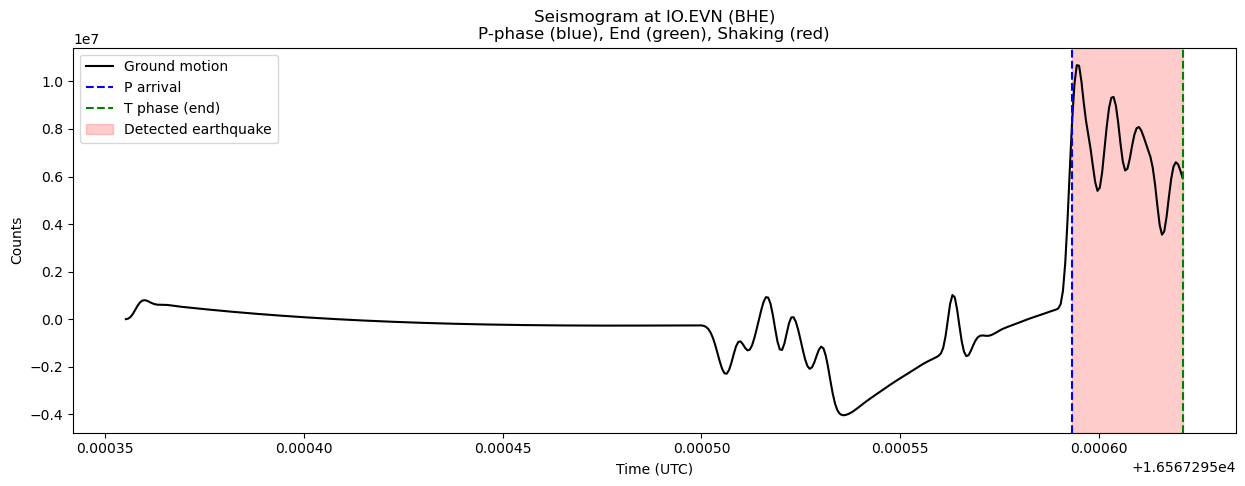


=== Event 37 at (35.76, 82.68) on 2012-08-12T10:47:05.300000Z ===
   Could not fetch seismogram for this event: No data available for request.
HTTP Status code: 204
Detailed response of server:



=== Event 38 at (27.83, 88.17) on 2011-09-18T12:40:47.300000Z ===
   Using station: IO.EVN (BHE)
   Could not fetch seismogram for this event: No data available for request.
HTTP Status code: 204
Detailed response of server:



=== Event 46 at (37.76, 95.76) on 2009-08-28T01:52:06.600000Z ===
   Could not fetch seismogram for this event: No data available for request.
HTTP Status code: 204
Detailed response of server:



=== Event 54 at (25.25, 97.75) on 2008-08-21T12:24:33.200000Z ===
   Could not fetch seismogram for this event: No data available for request.
HTTP Status code: 204
Detailed response of server:



=== Event 58 at (23.09, 101.11) on 2007-06-02T21:34:57.500000Z ===
   Could not fetch seismogram for this event: No data available for request.
HTTP Status code: 204
Detailed respo

,Event idx,Origin time,Epicentral area,Epicentre lat,Epicentre lon,Magnitude,Depth,is_shallow,is_climate_region,is_monsoon,P_phase_time,T_phase_time,station,channel,monsoon_total_precipitation_mm,monsoon_cumulative_precipitation_mm,seismic_trace_data,seismic_trace_stats
0,27,2015-05-12 07:36:52.900,nepal,27.62,86.21,6.3,2000.0,True,True,True,2015-05-12T07:37:12.850000Z,2015-05-12T07:37:19.700000Z,IO.EVN,BHE,None,[],"[-225.0516629138202, -1649.7843158985568, -582...","{'sampling_rate': 20.0, 'delta': 0.05, 'startt..."
1,28,2015-05-12 07:05:18.700,nepal,27.83,86.14,7.1,2000.0,True,True,True,2015-05-12T07:05:39.250000Z,2015-05-12T07:05:41.650000Z,IO.EVN,BHE,None,[],"[3561.9868074543374, 26261.181560244913, 93194...","{'sampling_rate': 20.0, 'delta': 0.05, 'startt..."


In [8]:
# Initialize an FDSN client to fetch seismic data from the GFZ data center.
client = Client("GFZ")

# Initialize an empty list to store dictionaries of event data, which will
# later be converted into a pandas DataFrame. This will also hold raw seismic data.

waveform_ok = []
event_table = []
# Loop through each row in the DataFrame that has been flagged as having a
# "probable_climate_interaction".
for idx, row in df[df["probable_climate_interaction"]].iterrows():
    lat = row["Epicentre latitude"]
    lon = row["Epicentre longitude"]
    t0 = UTCDateTime(row["Origin time"]) # Convert pandas datetime to ObsPy UTCDateTime

    # Print header for the current event being processed for clear progress tracking.
    print(f"\n=== Event {idx} at ({lat:.2f}, {lon:.2f}) on {t0} ===")

    try:
        # ----------------------------------------------------------------------------
        # Attempt to get information about broadband (BH?) seismic stations
        # within a 2-degree radius of the event, including their response information.
        inv = client.get_stations(latitude=lat, longitude=lon, maxradius=2, channel="BH?", level="response")

        # If no stations or networks are found in the inventory, skip this event.
        if not inv or not inv.networks:
            print("   No nearby broadband station found.")
            continue # Move to the next event in the loop

        # Extract network, station, channel, and location codes from the first available station.
        # Use an empty string if location_code is None.
        net = inv[0].code
        sta = inv[0][0].code
        cha = inv[0][0][0].code
        loc = inv[0][0][0].location_code or ""

        print(f"   Using station: {net}.{sta} ({cha})")

        # ----------------------------------------------------------------------------
        # Fetch waveform data for the selected station, starting from the event's origin time and extending for 30 minutes.
        st = client.get_waveforms(network=net, station=sta, location=loc, channel=cha,
                                  starttime=t0, endtime=t0 + 60 * 30)

        # Remove the mean from the waveform data. This is a common pre-processing step to prepare data for filtering and STA/LTA.
        st.detrend("demean")

        # Apply a bandpass filter to the waveform to remove unwanted frequencies
        # (e.g., very low frequency noise like tides or high frequency cultural noise).
        st.filter("bandpass", freqmin=0.02, freqmax=2) # Explain choice of frequency

        # Select the first (and likely only) trace from the Stream object.
        tr = st[0]

        # ----------------------------------------------------------------------------
        # STA/LTA P/T picker 
        
        # Calculate the number of samples for the short-term average (STA) window (1 second).
        nsta = int(1 * tr.stats.sampling_rate)
        # Calculate the number of samples for the long-term average (LTA) window (20 seconds).
        nlta = int(20 * tr.stats.sampling_rate)

        # Compute the Characteristic Function (CFT) using the classic STA/LTA algorithm.
        cft = classic_sta_lta(tr.data, nsta, nlta)

        # Apply a trigger to the CFT to detect onsets (P-phase) and offsets (T-phase/end of strong shaking).
        # Trigger 'on' threshold is 3, 'off' threshold is 1.
        on_of = trigger_onset(cft, 3, 1)

        p_time, t_time = None, None # Initialize phase times to None (REVISED-------------------------------)

        # If any on/off pairs are detected by the trigger.
        if len(on_of) > 0:
            p_sample = on_of[0][0] # The first sample of the first detected onset.
            t_sample = on_of[0][1] # The last sample of the first detected event.

            # Calculate the UTCDateTime for the P-phase arrival.
            p_time = tr.stats.starttime + (p_sample / tr.stats.sampling_rate)
            # Calculate the UTCDateTime for the T-phase (end of strong shaking).
            t_time = tr.stats.starttime + (t_sample / tr.stats.sampling_rate)

        # ----------------------------------------------------------------------------
        # Selected waveform DataFrame index 
        waveform_ok.append(idx)                     # <-- keep the DataFrame index


        # ----------------------------------------------------------------------------
        # Plotting
        _quick_plot(tr, p_time, t_time, net, sta, cha)


        # ----------------------------------------------------------------------------
        # Table info 

        try:
            stats_dict = tr.stats.as_dict()
        except Exception:
            stats_dict = dict(tr.stats)


        # Append the processed event's information to the event_table list.
        event_entry = {
            "Event idx": idx,
            "Origin time": row["Origin time"],
            "Epicentral area": row["Epicentral area"],
            "Epicentre lat": lat,
            "Epicentre lon": lon,
            "Magnitude": row.get("Magnitude value", None), # Use .get to safely retrieve Magnitude value, defaulting to None if not present.
            "Depth": row["Depth"],
            "is_shallow": row["is_shallow"],
            "is_climate_region": row["is_climate_region"],
            "is_monsoon": row["is_monsoon"],
            "P_phase_time": p_time,
            "T_phase_time": t_time, # (REVISED-------------------------------)
            "station": f"{net}.{sta}",
            "channel": cha,
            "monsoon_total_precipitation_mm": None, # Placeholder for ECMWF data, will be filled later
            "monsoon_cumulative_precipitation_mm": [], # Placeholder for cumulative sum
            "seismic_trace_data": tr.data.tolist(), # Store raw data as list (for pickling compatibility)
            "seismic_trace_stats": stats_dict # Store trace stats as dict (for pickling compatibility)
        }
        event_table.append(event_entry)
        # waveform_ok.append(idx)        # <-- keep the DataFrame index

    except Exception as e:
        # Catch any exceptions that occur during waveform fetching or processing
        # and print an informative error message.
        print(f"   Could not fetch seismogram for this event: {e}")
        # Optionally, add an entry to the table indicating failure, if needed
        # event_table.append({"Event idx": idx, "Error": str(e), ...})

# 3. Produce DataFrame summary (preliminary)
event_df = pd.DataFrame(event_table)
print("\nValidated earthquake events with detected P/T phases (preliminary):")
display(event_df)


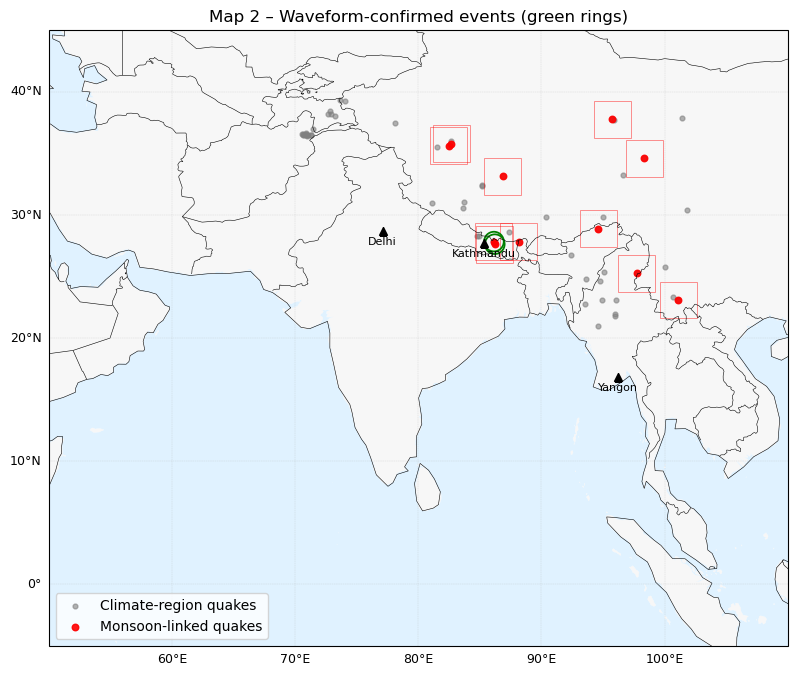

<GeoAxes: title={'center': 'Map 2 – Waveform-confirmed events (green rings)'}>

In [9]:
# ----------------------------------------------------------------------------
# 📍  Generic epicentre plotting helper 2
# ----------------------------------------------------------------------------

plot_epicentre_map(df,
                   highlight_idx=waveform_ok,
                   title="Map 2 – Waveform-confirmed events (green rings)")

#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
## 3. Retrieve and analyze ECMWF data for monsoon events: May–Sep precipitation
#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

In [32]:
# ------------------------------
# Documentation for this section:
# ------------------------------

# This section focuses on retrieving monthly total precipitation data from the
# ECMWF ERA5 reanalysis dataset for a region and time period relevant to each
# validated earthquake event. This data will be used to assess the precipitation
# conditions during the monsoon season when the seismic event occurred.

#
# To investigate if a seismic event coincides with an "exceptional monsoon event",
# we need reliable precipitation data. ERA5 is the fifth generation ECMWF
# reanalysis for the global climate and weather, providing hourly estimates
# of a large number of atmospheric, land, and oceanic climate variables.
# Monthly means are used here for a broader seasonal assessment.
#
# 4.1. Setup for ECMWF Data Retrieval:
#      - `cdsapi.Client()`: Initializes the client to interact with the
#        Copernicus Data Store (CDS). This requires prior setup of the
#        `.cdsapirc` file in the user's home directory with API credentials.
#      - `OUT_DIR_ERA5`: A specific directory is created to store the
#        downloaded NetCDF files, organized by event.
#
# 4.2. Iterating through Validated Events for Data Download:
#      The script iterates through the `event_df` (which contains events
#      for which seismograms were successfully retrieved and processed).
#      For each event, it dynamically constructs a request for ERA5 data:
#
#      a. Area of Interest (`AREA`):
#         A bounding box is defined around the earthquake's epicenter.
#         A buffer of +/- 1.5 degrees in latitude and longitude is used
#         to capture the regional precipitation patterns relevant to the event.
#         This dynamic approach ensures that the downloaded data is localized
#         to the vicinity of each specific earthquake.
#
#      b. Time Period (`year`, `month`):
#         The request is for the specific `year` of the earthquake's origin
#         and the `monsoon_months` (May through September, i.e., 05 to 09).
#         This aligns with the `is_monsoon` flag defined earlier and ensures
#         that we capture the full seasonal precipitation leading up to and
#         during the event.
#
#      c. Variable (`total_precipitation`):
#         `"total_precipitation"` is selected as the primary variable. This
#         represents the accumulated precipitation over the month (in meters).
#         It is the most direct measure for assessing monsoon intensity.
#         Other variables like wind components (`10m_u_component_of_wind`,
#         `10m_v_component_of_wind`) could also be requested for more detailed
#         monsoon analysis (e.g., wind circulation patterns) but are omitted
#         here for simplicity and focus on precipitation.
#
#      d. Data Format (`netcdf`):
#         The data is requested in NetCDF format, a common self-describing
#         format for scientific data, easily handled by libraries like `xarray`.
#
#      e. Error Handling and Skipping:
#         `try-except` blocks are used to catch any issues during the download.
#         The script also checks if a file for a specific event has already
#         been downloaded to avoid redundant requests.
#
# 4.3. Analysis of Downloaded Precipitation Data:
#      After downloading, the NetCDF file for each event is opened using `xarray`.
#      The `total_precipitation` values (which are in meters) are converted to
#      millimeters for easier interpretation. Both the total sum across the
#      monsoon months and the *cumulative sum* of monthly values are calculated.
#      The cumulative sum provides insight into the rainfall progression
#      throughout the monsoon season.
#
# 4.4. Defining "Exceptional Monsoon Event":
#      Based on meteorological literature (e.g., India Meteorological Department classifications):
#      - **Daily Extreme Rainfall**: While this script uses monthly data, daily thresholds
#        are often cited, e.g., "Very Heavy Rain" (124.5-244.4 mm/day), "Extremely Heavy Rain"
#        (>= 244.5 mm/day), "Exceptionally Heavy Rainfall" (a value near the highest recorded
#        rainfall for the month/season, exceeding 120 mm in a day). These are not directly
#        applicable to monthly means but inform the severity context.
#      - **Seasonal/Interannual Anomalies**: For a seasonal monsoon (like May-September
#        total precipitation in a region) to be considered "exceptional," it typically involves
#        comparison to a long-term climatological average (e.g., 30-year mean).
#        - **Excess Monsoon**: Often defined as a percentage departure of realized
#          rainfall from the long-period average (LPA) of +20% or more.
#        - **Above Normal**: When the total rainfall is greater than the LPA plus one
#          standard deviation (LPA + $\sigma$).
#        - **Below Normal / Deficient**: When the total rainfall is less than the LPA minus one
#          standard deviation (LPA - $\sigma$), or a percentage departure of -20% or more.
#      Therefore, the `monsoon_total_precipitation_mm` and `monsoon_cumulative_precipitation_mm`
#      values in the `event_df` provide the observed precipitation for the event's monsoon period.
#      To classify it as "exceptional," these values must be quantitatively compared against
#      historical means and standard deviations for the specific geographic area.
# ----------------------------------------------------------------------------
# ----------------------------------------------------------------------------

In [29]:
# ----------------------------------------------------------------------------
# earthquake epicentre (lat, lon)
#           └──> 3×3° box
#                     └──> ERA-5 monthly tp grids (May-Sep)
#                                 ├── sum over box (mm)
#                                 └── cumulative vector
# ----------------------------------------------------------------------------

In [11]:
import os, tempfile, cdsapi

# ------------------------------------------------------------------
# 0️⃣  Inject credentials **in-code** (or pick them from $ENV)
# ------------------------------------------------------------------

# The legacy CDS (…/api/v2) was retired on 26 Sep 2024. Use the new endpoint below and a
# Personal Access Token from https://cds.climate.copernicus.eu/profile
# Best practice: store these two lines in ~/.cdsapirc and then call cdsapi.Client() with no args.
os.environ.setdefault("CDSAPI_URL", "https://cds.climate.copernicus.eu/api")
os.environ.setdefault("CDSAPI_KEY", "PASTE-YOUR-PERSONAL-ACCESS-TOKEN-HERE")      # <— replace

# Tell cdsapi *not* to read ~/.cdsapirc
null_rc = "NUL" if os.name == "nt" else "/dev/null"
os.environ["CDSAPI_RC"] = null_rc                                                 # one-liner “mute” switch


# (If you prefer not to touch an env-var, pass url & key explicitly:)
url = os.environ["CDSAPI_URL"]
key = os.environ["CDSAPI_KEY"]

# Create the client – .cdsapirc will be skipped - `quiet=True` removes the banner & survey lines
cds_client = cdsapi.Client(url=url, key=key, quiet=True)


In [12]:
# Set up the CDS API client
# cds_client = cdsapi.Client()

# Output folder for NetCDF files
OUT_DIR_ERA5 = os.path.join(os.getcwd(), "epos_data", "era5_data")
os.makedirs(OUT_DIR_ERA5, exist_ok=True)

# Monsoon months (“05” → “09”)
MONSOON_MONTHS = [f"{m:02d}" for m in range(5, 10)]


ecmwf_downloaded_files = []

for i, row in tqdm(event_df.iterrows(),
                   total=len(event_df),
                   desc="ERA-5 download + parse"):

    event_idx = row["Event idx"]
    lat, lon  = row["Epicentre lat"], row["Epicentre lon"]
    year_str  = str(row["Origin time"].year)

    # 3×3° box  (North, West, South, East)  – CDS order
    area = [lat + 1.5, lon - 1.5,
            lat - 1.5, lon + 1.5]

    outfile = os.path.join(
        OUT_DIR_ERA5,
        f"era5_event_{event_idx}_{year_str}_monsoon.nc"
    )

    # ----------------------------------------------------------------------------
    # Download the NetCDF if absent

    if not os.path.exists(outfile):
        req = {
            "product_type": "monthly_averaged_reanalysis",
            "variable": "total_precipitation",
            "year": [year_str],
            "month": MONSOON_MONTHS,
            "time": "00:00",
            "area": area,
            "data_format": "netcdf",
        }
        try:
            cds_client.retrieve(
                "reanalysis-era5-single-levels-monthly-means",
                req,
                outfile
            )
            print(f"   ✔ downloaded {outfile}")
        except Exception as e:
            # Even if retrieve complains, a partial/complete file is often written
            print(f"   ⚠ retrieve raised ({e}); will still attempt to read file")

    # ----------------------------------------------------------------------------
    # Parse the file (whether pre-existing or just downloaded)

    total_mm      = None
    cumulative_mm = []

    if os.path.exists(outfile):
        try:
            ds = xr.open_dataset(outfile)

            if "tp" in ds and ds["tp"].size:
                # ---- total for the whole 5-month season ------------------
                # (ERA-5 stores metres of water; multiply by 1000 → mm)
                total_mm = float(ds["tp"].sum() * 1000)

                # ---- month-by-month cumulative series --------------------
                # 1. sum each month over the 3×3° box  (lat, lon dims)
                # 2. convert to mm
                # 3. take the running cumulative
                monthly_series = (
                    ds["tp"].sum(dim=["latitude", "longitude"]) * 1000
                )
                cumulative_mm = monthly_series.cumsum().values.tolist()

                # record success
                ecmwf_downloaded_files.append(outfile)
                print(f"   → {total_mm:.1f} mm total")

            else:
                print("'tp' variable missing or empty")

            ds.close()

        except Exception as e:
            print(f"could not open/parse {outfile}: {e}")

    else:
        print("file not found on disk")

    # ----------------------------------------------------------------------------
    # Store results back into event_df

    event_df.at[i, "monsoon_total_precipitation_mm"]       = total_mm
    event_df.at[i, "monsoon_cumulative_precipitation_mm"] = cumulative_mm

ERA-5 download + parse: 100%|█████████████████████| 2/2 [00:03<00:00,  1.73s/it]

   → 6376.4 mm total
   → 6074.4 mm total


In [13]:
print("\nFinal validated earthquake events with ERA-5 monsoon precipitation:")
display(event_df)


Final validated earthquake events with ERA-5 monsoon precipitation:


,Event idx,Origin time,Epicentral area,Epicentre lat,Epicentre lon,Magnitude,Depth,is_shallow,is_climate_region,is_monsoon,P_phase_time,T_phase_time,station,channel,monsoon_total_precipitation_mm,monsoon_cumulative_precipitation_mm,seismic_trace_data,seismic_trace_stats
0,27,2015-05-12 07:36:52.900,nepal,27.62,86.21,6.3,2000.0,True,True,True,2015-05-12T07:37:12.850000Z,2015-05-12T07:37:19.700000Z,IO.EVN,BHE,6376.391411,"[501.55859375, 1704.1455078125, 3315.3828125, ...","[-225.0516629138202, -1649.7843158985568, -582...","{'sampling_rate': 20.0, 'delta': 0.05, 'startt..."
1,28,2015-05-12 07:05:18.700,nepal,27.83,86.14,7.1,2000.0,True,True,True,2015-05-12T07:05:39.250000Z,2015-05-12T07:05:41.650000Z,IO.EVN,BHE,6074.408531,"[469.04632568359375, 1620.835693359375, 3150.4...","[3561.9868074543374, 26261.181560244913, 93194...","{'sampling_rate': 20.0, 'delta': 0.05, 'startt..."


#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
## 4.  Monsoon-Severity Rating (based on literature thresholds)
#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

Literature touchpoints
----------------------
• India Meteorological Department (IMD) all-India long-period average (LPA)
  for the Southwest Monsoon (Jun–Sep) ≈ **880 mm**; σ ≈ 90 mm.
  
• “Excess” monsoon years are > LPA + 20 %  (≈ 1056 mm).

• Two-sigma wet seasons (LPA + 2σ) ≈ **1060–1100 mm** can be treated as
  “exceptional” in Himalayan hydro-seismic studies (e.g., Bettinelli 2008).

We adopt the following rule-of-thumb bands for total May–Sep precipitation
inside the 3 × 3 ° box around each quake:

    ≥1100 mm   →  Exceptional (“very wet”)
    880–1100 mm→  Above-normal / Wet
    700–880 mm →  Normal
    <700 mm    →  Deficient / Dry


In [14]:
def classify_monsoon(total_mm):
    if pd.isna(total_mm):
        return "Unknown"
    if total_mm >= 1100:
        return "Exceptional"
    elif total_mm >= 880:
        return "Wet"
    elif total_mm >= 700:
        return "Normal"
    else:
        return "Dry"

In [15]:
event_df["monsoon_class"] = event_df["monsoon_total_precipitation_mm"].apply(classify_monsoon)
summary_counts = event_df["monsoon_class"].value_counts().to_dict()




print("\n──────── Climate–Seismicity Summary ────────")
for cls in ["Exceptional", "Wet", "Normal", "Dry", "Unknown"]:
    if cls in summary_counts:
        print(f"{cls:<12}: {summary_counts[cls]} event(s)")
print("────────────────────────────────────────────")


──────── Climate–Seismicity Summary ────────
Exceptional : 2 event(s)
────────────────────────────────────────────


In [16]:
# ----------------------------------------------------------------------------
#  📍  7b. Identify “Exceptional” rainfall events for mapping
# ----------------------------------------------------------------------------

exceptional_idx = event_df.loc[
    event_df["monsoon_class"] == "Exceptional", "Event idx"].tolist()                # list of DataFrame indices (may be empty)

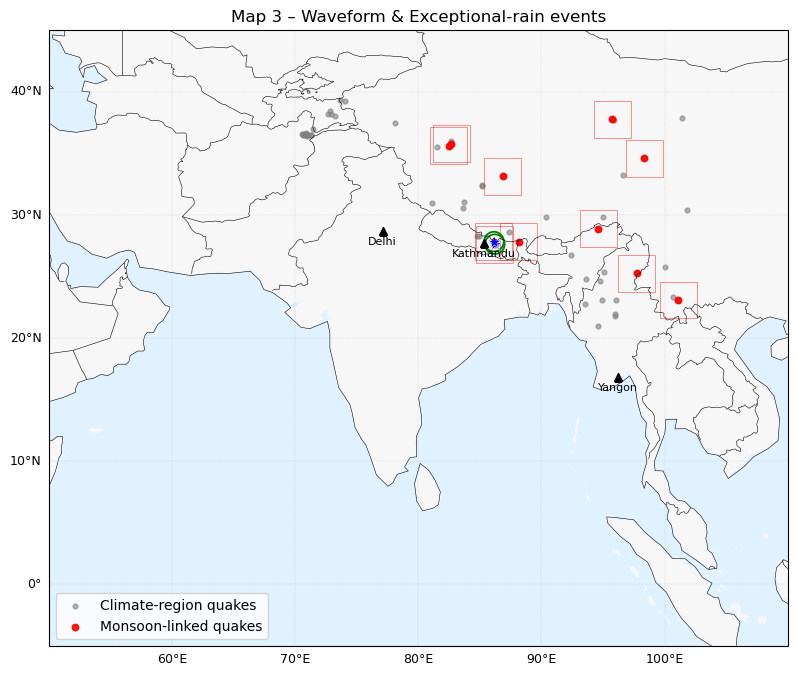

<GeoAxes: title={'center': 'Map 3 – Waveform & Exceptional-rain events'}>

In [17]:
plot_epicentre_map(df,
                   highlight_idx=waveform_ok,          # green rings
                   exceptional_idx=exceptional_idx,    # blue stars
                   title="Map 3 – Waveform & Exceptional-rain events")


#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
## 5. Climatology precipitation: Extracting rainfall flux (era5_data)
#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

In [18]:

def era5_monsoon_total(lat, lon, year):
    """
    Download (if needed) and return May–Sep ERA-5 total precipitation (mm)
    for a 3×3° box centred on (lat, lon).
    NetCDFs are cached in BASELINE_DIR.
    """
    area   = [lat + 1.5, lon - 1.5, lat - 1.5, lon + 1.5]  # N W S E
    months = [f"{m:02d}" for m in range(5, 10)]
    target = pathlib.Path(BASELINE_DIR) / f"era5_{year}_monsoon.nc"

    if not target.exists():
        print(f"↳ downloading ERA-5 {year} to {target.name}")
        cdsapi.Client().retrieve(
            "reanalysis-era5-single-levels-monthly-means",
            {"product_type":"monthly_averaged_reanalysis",
             "variable":"total_precipitation",
             "year":[str(year)],
             "month": months,
             "time":"00:00",
             "area": area,
             "data_format":"netcdf"},
            str(target)
        )

    ds = xr.open_dataset(target)
    total_mm = float(ds["tp"].sum() * 1000)    # m → mm
    ds.close()
    return total_mm

In [19]:
import pathlib as Path, pathlib


BASELINE_DIR = os.path.join(os.getcwd(), "epos_data", "era5_baseline")
os.makedirs(BASELINE_DIR, exist_ok=True) 

# Build 30-year baseline & z-score for 2015
# cache so identical boxes are done once
baseline_cache = {}

for i, row in tqdm(event_df.iterrows(),
                   total=len(event_df),
                   desc="30-yr climatology"):

    obs = row["monsoon_total_precipitation_mm"]
    if pd.isna(obs):
        continue                        # skip events without precipitation

    lat, lon = float(row["Epicentre lat"]), float(row["Epicentre lon"])
    epic_key = (round(lat,2), round(lon,2))   # key per grid box

    if epic_key not in baseline_cache:
        # build 1991-2020 series once
        series = [era5_monsoon_total(lat, lon, y) for y in range(1991, 2021)] # 
        μ, σ   = np.mean(series), np.std(series, ddof=1)
        baseline_cache[epic_key] = (μ, σ)

    μ, σ = baseline_cache[epic_key]
    z    = (obs - μ) / σ if σ else np.nan

    event_df.at[i, "clim_mean_mm"]   = μ
    event_df.at[i, "clim_sigma_mm"]  = σ
    event_df.at[i, "monsoon_z"]      = z

# quick peek
print(event_df[["Event idx","monsoon_total_precipitation_mm",
                "clim_mean_mm","clim_sigma_mm","monsoon_z"]])




30-yr climatology: 100%|██████████████████████████| 2/2 [00:00<00:00,  6.61it/s]

   Event idx monsoon_total_precipitation_mm  clim_mean_mm  clim_sigma_mm  \
0         27                    6376.391411   6028.986343     686.296858   
1         28                    6074.408531   6028.986343     686.296858   

   monsoon_z  
0   0.506202  
1   0.066184  


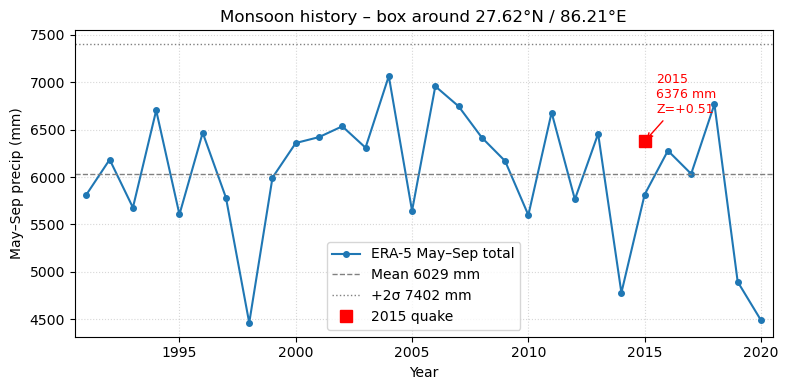

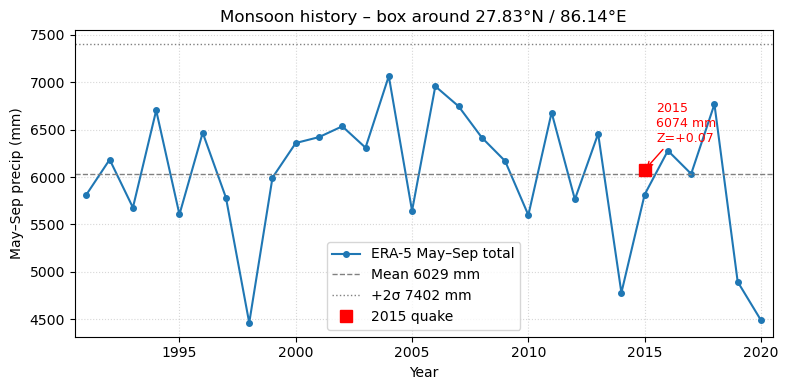

In [20]:
# ----------------------------------------------------------------------------
# Time-series context plot – 30-yr ERA-5 monsoon totals
# ----------------------------------------------------------------------------


for _, ev in event_df.dropna(subset=["monsoon_z"]).iterrows():
    lat, lon   = ev["Epicentre lat"], ev["Epicentre lon"]
    epic_key   = (round(lat,2), round(lon,2))
    μ, σ       = baseline_cache[epic_key]
    series     = [era5_monsoon_total(lat, lon, y) for y in range(1991, 2021)]
    obs_year   = ev["Origin time"].year
    obs_total  = ev["monsoon_total_precipitation_mm"]
    z          = ev["monsoon_z"]

    # --- plot (same style as before) ----------------------------------
    years = list(range(1991, 2021))
    fig, ax = plt.subplots(figsize=(8,4))
    ax.plot(years, series, "-o", ms=4, label="ERA-5 May–Sep total")
    ax.axhline(μ,          ls="--", color="gray", lw=1,  label=f"Mean {μ:.0f} mm")
    ax.axhline(μ+2*σ, ls=":",  color="gray", lw=1,  label=f"+2σ {μ+2*σ:.0f} mm")
    ax.plot(obs_year, obs_total, "s", ms=8, color="red",
            label=f"{obs_year} quake")
    ax.annotate(f"{obs_year}\n{obs_total:.0f} mm\nZ={z:+.2f}",
                xy=(obs_year, obs_total),
                xytext=(obs_year+0.5, obs_total+300),
                arrowprops=dict(arrowstyle="->", color="red"),
                color="red", fontsize=9)
    ax.set_xlabel("Year"); ax.set_ylabel("May–Sep precip (mm)")
    ax.set_title(f"Monsoon history – box around {lat:.2f}°N / {lon:.2f}°E")
    ax.set_xlim(1990.5, 2020.5); ax.grid(ls=":", alpha=0.5)
    ax.legend(); plt.tight_layout(); plt.show()


#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
## 6. Build a multimodal pickle archiving
#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

### Documentation for this section:

This section gathers all key outputs and intermediate data into a single
Python dictionary and saves it to a binary file using the 'pickle' module.
This allows for convenient archiving and later retrieval of the entire
analysis state, including DataFrames, raw seismic data, images , and references to
downloaded climate data.


The `pickle` module serializes Python objects into a byte stream, allowing
them to be written to a file and deserialized back into Python objects.
This is ideal for saving complex, heterogeneous data structures.

In [21]:
import pickle, gzip, io, hashlib, platform
from datetime import datetime, timezone
from pathlib import Path

In [22]:
# Helper – Matplotlib-figure → PNG bytes

def fig2png_bytes(fig, dpi: int = 150) -> bytes:
    """Return a Matplotlib figure as compressed PNG bytes (no disk I/O)."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
    png = buf.getvalue()
    buf.close()
    return png

In [23]:
# Metadata block  (auto-filled, nothing hard-coded)

metadata = {
    "script_version"      : "clim-seis v1.0",
    "run_timestamp_utc"   : datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "python_version"      : platform.python_version(),
    "probable_flag_logic" : "depth ≤ 10 km & Mw ≥ 4.5 & keyword region & month 5-9",
    "waveform_ok_indices" : waveform_ok,              # e.g. [16, 21, 25, …]
    "n_events_validated"  : len(event_table),
}

In [24]:
figures_png: dict[str, bytes] = {}

if plt.get_fignums():                               # any figure still open?
    last_fig = plt.gcf()
    figures_png["map_wave_exc"] = fig2png_bytes(last_fig)

In [25]:
# Climate grids – read each downloaded NetCDF once & put into a dict Key rule:  'event_<Event idx padded to 3>'

climate_grids: dict[str, xr.Dataset] = {}

for ev in event_table:
    evt_id  = ev["Event idx"]
    year    = ev["Origin time"].year
    key     = f"event_{evt_id:03d}"

    # look for a file that matches this event
    pattern = f"era5_event_{evt_id}_{year}_monsoon*.nc"
    nc_files = list(Path(OUT_DIR_ERA5).glob(pattern))
    if not nc_files:
        # nothing was downloaded (or failed) for this event
        continue

    try:
        ds = xr.open_dataset(nc_files[0])      # load lazily
        climate_grids[key] = ds
    except Exception as err:
        print(f"⚠  could not open {nc_files[0].name}: {err}")



In [26]:
# Assemble *all* outputs in one top-level dictionary

all_outputs = dict(
    metadata          = metadata,            # Textual data
    catalog_raw       = original_df,         # full CSV as loaded
    catalog_filtered  = event_df,            # only waveform-validated rows
    waveforms         = event_table,         # list[dict]   (raw traces & picks)
    climate_grids     = climate_grids,       # dict[str → xr.Dataset]
    figures_png       = figures_png,         # dict[str → PNG bytes]
    # empty slots for future modalities
    ml_models         = None,
    literature_cache  = [],
)



In [27]:
# Write the pickle with gzip compression

out_file = Path("clim_seis_multimodal.pkl.gz")
with gzip.open(out_file, "wb") as f:
    pickle.dump(all_outputs, f, protocol=pickle.HIGHEST_PROTOCOL)

sha = hashlib.sha256(out_file.read_bytes()).hexdigest()[:12]
print(f"Pickle archive written → {out_file}   (sha256:{sha})")



Pickle archive written → clim_seis_multimodal.pkl.gz   (sha256:4367edeae47c)


#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
## 7. Reference summary for Methods Section, Documentation, or Report
#### ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

- Allen, R. V. (1978). Automatic earthquake recognition and timing from single traces.
  Bulletin of the Seismological Society of America, 68(5), 1521-1532.
  [No DOI provided in original context, standard reference for STA/LTA]
- Amos, C.B., et al. (2014), "Seasonal strain and microseismicity in the Himalaya induced by surface hydrology",
  Nature, 510, 496–499. [https://doi.org/10.1038/nature13202]
- Bettinelli, P., et al. (2008), "Seasonal surface loading and the modulation of seismicity in the Himalaya",
  Nature Geoscience, 1, 44–48. [https://doi.org/10.1038/ngeo251]
- Bookhagen, B. & Burbank, D.W. (2010), "Toward a tectonic geomorphology of the Himalaya and Tibet",
  Nature Geoscience, 3, 611–617. [https://doi.org/10.1038/ngeo907]
- Copernicus Climate Change Service (C3S) (2017): ERA5: Fifth generation of ECMWF atmospheric reanalyses
  of the global climate. Copernicus Climate Change Service Climate Data Store (CDS).
  (Accessed on 07-JUN-2025), [https://cds.climate.copernicus.eu/cdsapp#!/dataset/reanalysis-era5-single-levels-monthly-means?tab=overview]
- Craig, T. J., et al. (2017). Hydrological loading drives daily earthquake cycles in the Himalayas.
  Nature Communications, 8(1), 15696. [https://doi.org/10.1038/ncomms15696]
- India Meteorological Department (IMD) Glossary and FAQs on Monsoon (various dates, accessed via search results).
- Mayer, H., et al. (2014), "Influence of hydrological loading on seasonal variations in seismicity in the Himalaya",
  Earth Surface Dynamics, 2(2), 455–465. [https://doi.org/10.5194/esurf-2-455-2014]
- ObsPy Project (https://docs.obspy.org/)
- Pérez-Guillén, C., et al. (2022). Precipitation‐induced stress changes control seismicity in a dry, mountainous region.
  Geophysical Research Letters, 49(23), e2022GL100746. [https://doi.org/10.1029/2022GL100746]
- Sun, C., et al. (2020). Seasonal Modulations of Microseismicity in the Longmen Shan Thrust Belt, Eastern Tibetan Plateau.
  Journal of Geophysical Research: Solid Earth, 125(3), e2019JB018823. [https://doi.org/10.1029/2019JB018823]
- Trani, D. (2010). Automated Real-time Detection of Seismic Events.
  Masters thesis, Politecnico di Torino. [No DOI provided in original context, standard reference for STA/LTA]
- Turner, A.G. & Annamalai, H. (2012), "Climate change and the South Asian summer monsoon",
  Nature Climate Change, 2, 587–595. [https://doi.org/10.1038/nclimate1495]
